## Import Libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    GridSearchCV
)

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

### Load Dataset

In [2]:
df = pd.read_csv("complated_clean_data.csv")

In [3]:
df.head()

,age,annual_income_inr,credit_score,credit_utilization_ratio,missed_payments_12m,avg_late_payment_days,monthly_transaction_count,monthly_spend_inr,cash_advance_count_6m,complaints_last_6m,...,region_Central,region_East,region_North,region_South,region_West,employment_type_Retired,employment_type_Salaried,employment_type_Self-Employed,employment_type_Student,employment_type_Unemployed
0,0.640070,2.544216,0.056847,-1.353085,0.264743,-0.744091,-1.080157,1.281490,-0.794708,2.379502,...,0,0,0,1,0,0,1,0,0,0
1,-0.702181,-0.527484,-0.510177,-0.281153,0.264743,-0.934479,-2.243812,-1.044769,0.447023,0.863791,...,1,0,0,0,0,0,1,0,0,0
2,-0.031055,-0.095225,0.785877,-1.081397,-0.884685,-0.281721,-0.830803,0.436257,1.688754,0.863791,...,0,1,0,0,0,0,1,0,0,0
3,-0.798056,-0.141232,-2.033039,0.385717,1.988886,2.288516,1.579625,-0.342629,0.447023,2.379502,...,0,0,1,0,0,0,0,0,0,1
4,-0.031055,-0.013765,0.866880,0.118969,0.264743,1.322977,1.247152,0.597326,-0.794708,0.863791,...,0,1,0,0,0,0,0,1,0,0


### Features and Target

In [4]:
X = df.drop("risk_status", axis=1)

y = df["risk_status"]

In [5]:
X = pd.get_dummies(X,drop_first=True)

### Train Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

## Decision Tree Hyperparameter Tuning

### Define Parameter Grid

In [7]:
dt_params = {

    "criterion": ["gini","entropy"],

    "max_depth": [3,5,7,10,15,None],

    "min_samples_split": [2,5,10,20],

    "min_samples_leaf": [1,2,4,8]
}

## Randomized Search CV

In [8]:
dt_random = RandomizedSearchCV(

    estimator=DecisionTreeClassifier(
        random_state=42
    ),
    param_distributions=dt_params,
    n_iter=20,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

In [9]:
dt_random.fit(X_train,y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versio

### Best Parameters

In [10]:
print("Best Parameters")

print(dt_random.best_params_)

Best Parameters
{'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 15, 'criterion': 'gini'}


### Best Decision Tree

In [11]:
best_dt = dt_random.best_estimator_

y_pred_dt = best_dt.predict(X_test)

### Evaluation

In [12]:
print("Accuracy :",accuracy_score(y_test,y_pred_dt))

print("Precision :",precision_score(y_test,y_pred_dt))

print("Recall :",recall_score(y_test,y_pred_dt))

print("F1 Score :",f1_score(y_test,y_pred_dt))

Accuracy : 0.9652173913043478
Precision : 0.8558558558558559
Recall : 0.8558558558558559
F1 Score : 0.8558558558558559


## Random Forest Hyperparameter Tuning

### Parameter Grid

In [13]:
rf_params = {

    "n_estimators":[100,200,300],

    "max_depth":[5,10,15,None],

    "min_samples_split":[2,5,10],

    "min_samples_leaf":[1,2,4]
}

### Grid Search CV

In [14]:
rf_grid = GridSearchCV(

    estimator=RandomForestClassifier(
        random_state=42
    ),

    param_grid=rf_params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

In [15]:
rf_grid.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and param

### Best Parameters

In [16]:
print("Best Parameters")

print(rf_grid.best_params_)

Best Parameters
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}


In [17]:
best_rf = rf_grid.best_estimator_

y_pred_rf = best_rf.predict(X_test)

### Evaluation

In [18]:
print("Accuracy :",accuracy_score(y_test,y_pred_rf))

print("Precision :",precision_score(y_test,y_pred_rf))

print("Recall :",recall_score(y_test,y_pred_rf))

print("F1 Score :",f1_score(y_test,y_pred_rf))

Accuracy : 0.9978260869565218
Precision : 0.990990990990991
Recall : 0.990990990990991
F1 Score : 0.990990990990991


### Classification Report

In [19]:
print(classification_report(
    y_test,
    y_pred_rf
))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       809
         1.0       0.99      0.99      0.99       111

    accuracy                           1.00       920
   macro avg       0.99      0.99      0.99       920
weighted avg       1.00      1.00      1.00       920



### Compare Tuned Models

In [20]:
comparison = pd.DataFrame({

    "Model":[
        "Tuned Decision Tree",
        "Tuned Random Forest"
    ],

    "Accuracy":[
        accuracy_score(y_test,y_pred_dt),
        accuracy_score(y_test,y_pred_rf)
    ],

    "Precision":[
        precision_score(y_test,y_pred_dt),
        precision_score(y_test,y_pred_rf)
    ],

    "Recall":[
        recall_score(y_test,y_pred_dt),
        recall_score(y_test,y_pred_rf)
    ],

    "F1 Score":[
        f1_score(y_test,y_pred_dt),
        f1_score(y_test,y_pred_rf)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Tuned Decision Tree,0.965217,0.855856,0.855856,0.855856
1,Tuned Random Forest,0.997826,0.990991,0.990991,0.990991


### Visualization

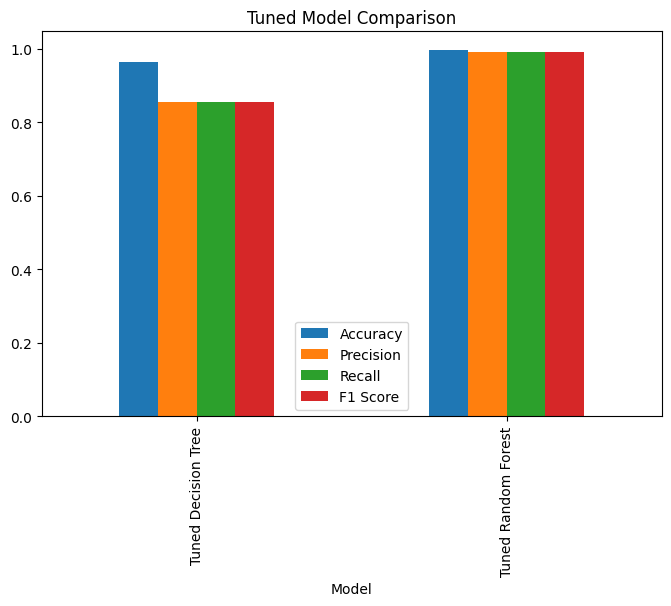

In [21]:
import matplotlib.pyplot as plt

comparison.set_index("Model").plot(
    kind="bar",
    figsize=(8,5)
)

plt.title(
    "Tuned Model Comparison"
)

plt.show()

## Conclusion

Hyperparameter tuning was performed to improve the predictive performance of both Decision Tree and Random Forest models.

RandomizedSearchCV efficiently identified the best Decision Tree parameters, while GridSearchCV exhaustively searched for the optimal Random Forest configuration.

The tuned Random Forest model achieved superior performance in terms of Recall and F1 Score, making it the most suitable model for identifying high-risk customers.

Therefore, the tuned Random Forest model was selected as the final predictive model for customer risk classification.